## STAT 306 Project: Vancouver Land Value Associated with Prior Year Values and Age

In [1]:
library(tidyverse)
library(broom)
library(ggplot2)
library(car)
library(GGally)
library(broom)

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'car' was built under R version 4.5.2"
Loading required package: carData

Warning message:
"package 'carData' was built under R version 4.5.2"

Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode


The following object is masked from 'package:purrr':

    some


Warning message:
"package 'GGally' was built under R version 4.5.2"


--------------------------
#### Data cleaning

In [47]:
set.seed(306)

property_sample <- read.csv(file = "data\\sample_data.csv")

property_cleaned <- property_sample |>  
                    select(
                        LEGAL_TYPE, 
                        ZONING_CLASSIFICATION, 
                        CURRENT_LAND_VALUE,
                        CURRENT_IMPROVEMENT_VALUE, 
                        PREVIOUS_LAND_VALUE, 
                        PREVIOUS_IMPROVEMENT_VALUE, 
                        YEAR_BUILT,
                        ) |>
                    na.omit() |>
                    filter(
                        CURRENT_IMPROVEMENT_VALUE > 0 & 
                        PREVIOUS_IMPROVEMENT_VALUE > 0
                        )

# Check how many rows were dropped
nrow(property_sample) - nrow(property_cleaned) 

head(property_cleaned)

[1] 102

,LEGAL_TYPE,ZONING_CLASSIFICATION,CURRENT_LAND_VALUE,CURRENT_IMPROVEMENT_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT
,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<int>
1,LAND,Residential Inclusive,1947000,34600,1977000,37800,1961
2,LAND,One-Family Dwelling,1324000,281000,1530000,274000,1995
3,STRATA,Comprehensive Development,336000,199000,315000,187000,1985
4,STRATA,Industrial,1898000,228000,1879000,225000,1990
5,STRATA,Comprehensive Development,252000,16700,216000,17300,1975
6,LAND,One-Family Dwelling,2939000,147000,2708000,129000,1964


--------------------------
#### EDA

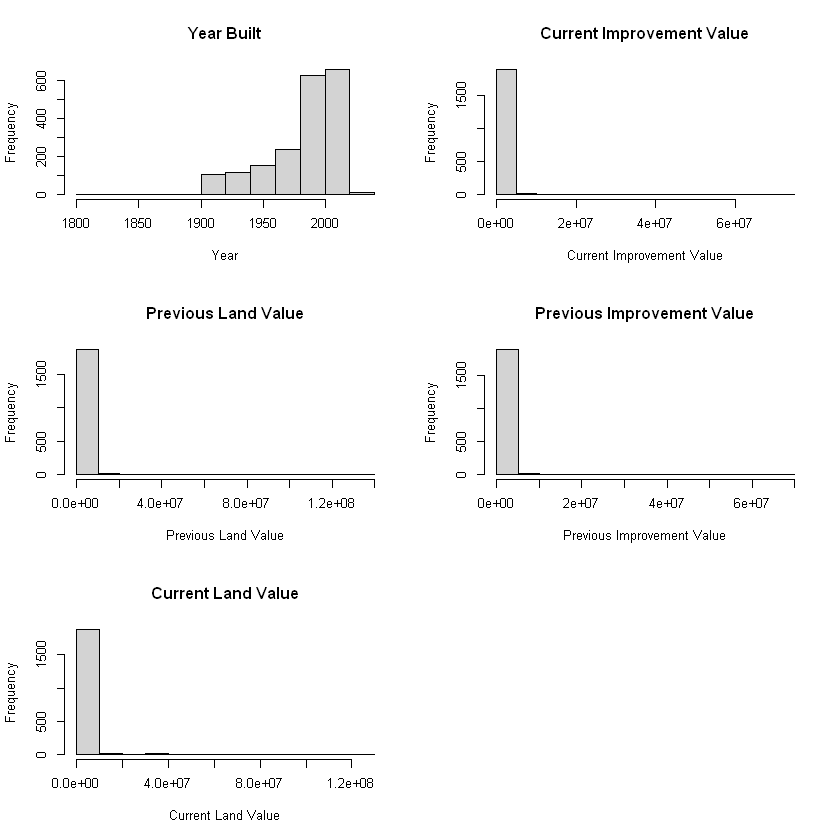

In [77]:
# Distribution Check
par(mfrow = c(3,2))
hist(property_cleaned$YEAR_BUILT,
     main = "Year Built",
     xlab = "Year")
hist(x = (property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Current Improvement Value", xlab = "Current Improvement Value")
hist(x = (property_cleaned$PREVIOUS_LAND_VALUE), main = "Previous Land Value", xlab = "Previous Land Value")
hist(x = (property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "Previous Improvement Value", xlab = "Previous Improvement Value")
hist(x = (property_cleaned$CURRENT_LAND_VALUE), main = "Current Land Value", xlab = "Current Land Value")

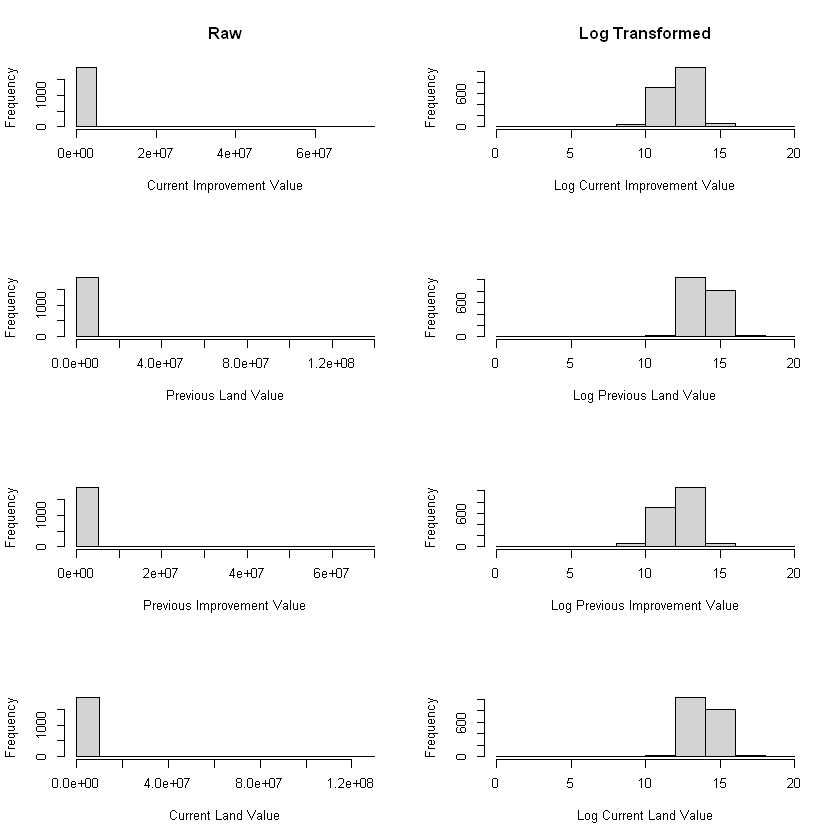

In [51]:
# Log-transformation Justification
par(mfrow = c(4,2))
hist(x = (property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Raw", xlab = "Current Improvement Value")
hist(x = log(property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Log Transformed", xlab = "Log Current Improvement Value")
hist(x = (property_cleaned$PREVIOUS_LAND_VALUE), main = "", xlab = "Previous Land Value")
hist(x = log(property_cleaned$PREVIOUS_LAND_VALUE), main = "", xlab = "Log Previous Land Value")
hist(x = (property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "", xlab = "Previous Improvement Value")
hist(x = log(property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "", xlab = "Log Previous Improvement Value")
hist(x = (property_cleaned$CURRENT_LAND_VALUE), main = "", xlab = "Current Land Value")
hist(x = log(property_cleaned$CURRENT_LAND_VALUE), main = "", xlab = "Log Current Land Value")

In [65]:
# Class Imbalance Check
counts1 <- table(property_cleaned$LEGAL_TYPE)
counts1

round(100 * prop.table(table(property_cleaned$LEGAL_TYPE)), 2)

counts2 <- table(property_cleaned$ZONING_CLASSIFICATION)
counts2

round(100 * prop.table(table(property_cleaned$ZONING_CLASSIFICATION)), 2)


  LAND  OTHER STRATA 
   754      1   1143 


  LAND  OTHER STRATA 
 39.73   0.05  60.22 


                                         Commercial Comprehensive Development 
                        8                       158                       700 
          Historical Area                Industrial       Limited Agriculture 
                       27                        55                         1 
        Multiple Dwelling       One-Family Dwelling                     Other 
                      125                       245                         4 
              Residential     Residential Inclusive       Two-Family Dwelling 
                      218                       304                        53 


                                         Commercial Comprehensive Development 
                     0.42                      8.32                     36.88 
          Historical Area                Industrial       Limited Agriculture 
                     1.42                      2.90                      0.05 
        Multiple Dwelling       One-Family Dwelling                     Other 
                     6.59                     12.91                      0.21 
              Residential     Residential Inclusive       Two-Family Dwelling 
                    11.49                     16.02                      2.79 

In [88]:
# Response vs Covariates
png("scatterplots.png", width = 700, height = 400)

par(mfrow = c(1, 3))

plot(log(property_cleaned$PREVIOUS_LAND_VALUE),
     log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     col = rgb(0, 0, 0, 0.3),
     xlab = "log(PREVIOUS_LAND_VALUE)",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs PLV")

plot(log(property_cleaned$PREVIOUS_IMPROVEMENT_VALUE),
     log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     col = rgb(0, 0, 0, 0.3),
     xlab = "log(PREVIOUS_IMPROVEMENT_VALUE)",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs PIV")

plot(property_cleaned$YEAR_BUILT,
     log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     col = rgb(0, 0, 0, 0.3),
     xlab = "YEAR_BUILT",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs Year Built")

dev.off()

agg_record_99888627 
                  2

--------------------------
#### Variable Selection

In [ ]:
full_model <- lm(
  log(CURRENT_LAND_VALUE) ~ 
    log(PREVIOUS_LAND_VALUE) +
    log(PREVIOUS_IMPROVEMENT_VALUE) +
    YEAR_BUILT +
    LEGAL_TYPE +
    ZONING_CLASSIFICATION,
  data = property_cleaned
)

--------------------------
#### Fitting Models

In [42]:
fit <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property2)
bb <- coef(fit)

In [43]:
summary(fit)
tidy(vif(fit)) %>% rename(Predictor = names, VIF = x)


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.48731 -0.05484  0.00512  0.05893  0.54142 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      0.8766076  0.2134483   4.107 4.17e-05 ***
log(PREVIOUS_LAND_VALUE)         0.9843750  0.0030502 322.728  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0049508  0.0026529   1.866 0.062163 .  
YEAR_BUILT                      -0.0003581  0.0001033  -3.466 0.000539 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1048 on 1996 degrees of freedom
Multiple R-squared:  0.9879,	Adjusted R-squared:  0.9879 
F-statistic: 5.453e+04 on 3 and 1996 DF,  p-value: < 2.2e-16


Warning message in tidy.numeric(vif(fit)):
"'tidy.numeric' is deprecated.
See help("Deprecated")"


Predictor,VIF
<chr>,<dbl>
log(PREVIOUS_LAND_VALUE),1.552479
log(PREVIOUS_IMPROVEMENT_VALUE),1.584497
YEAR_BUILT,1.692259


--------------------------
#### Analysis Plots

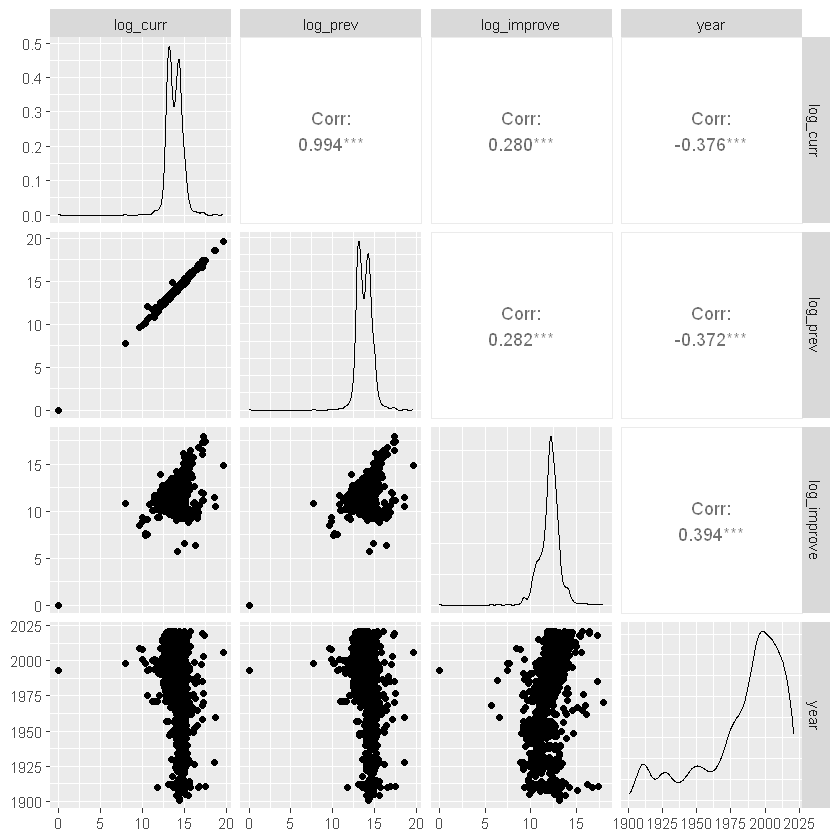

In [44]:
property_log <- property2 |>
                mutate(log_curr = log(CURRENT_LAND_VALUE),
                log_prev = log(PREVIOUS_LAND_VALUE),
                log_improve = log(PREVIOUS_IMPROVEMENT_VALUE),
                year = as.numeric(YEAR_BUILT)) |>
                select(log_curr, log_prev, log_improve, year)
ggpairs(property_log)

`geom_smooth()` using formula = 'y ~ x'


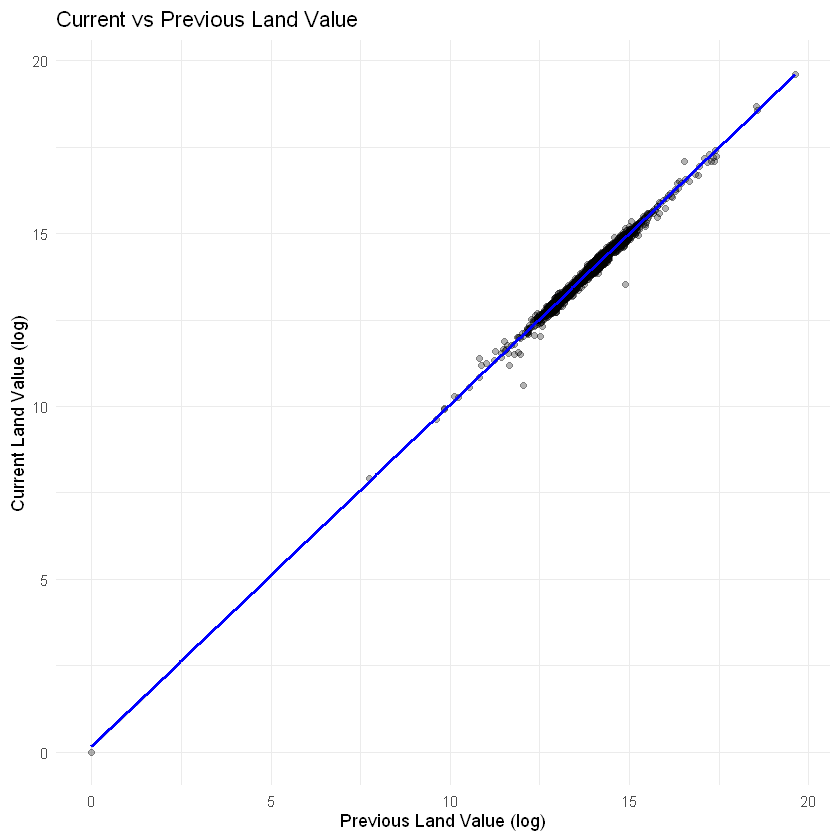

In [45]:
ggplot(property2, aes(x = log(PREVIOUS_LAND_VALUE), y = log(CURRENT_LAND_VALUE))) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(x = "Previous Land Value (log)", 
       y = "Current Land Value (log)",
       title = "Current vs Previous Land Value") +
  theme_minimal()

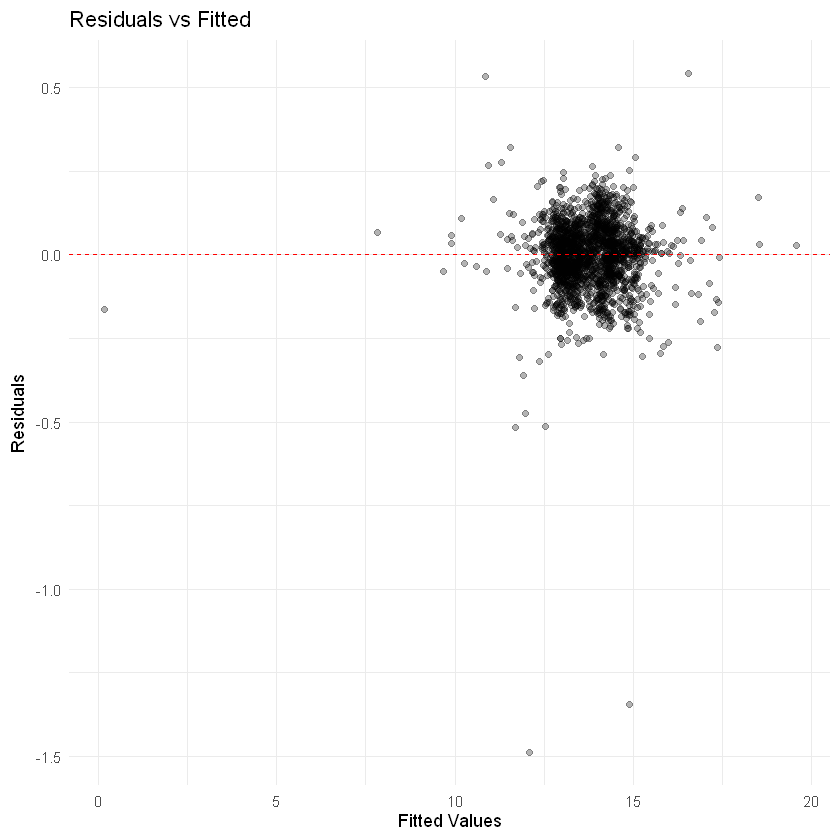

In [46]:
ggplot(data.frame(fitted = fit$fitted.values, residuals = fit$residuals),
       aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(x = "Fitted Values", y = "Residuals",
       title = "Residuals vs Fitted") +
  theme_minimal()

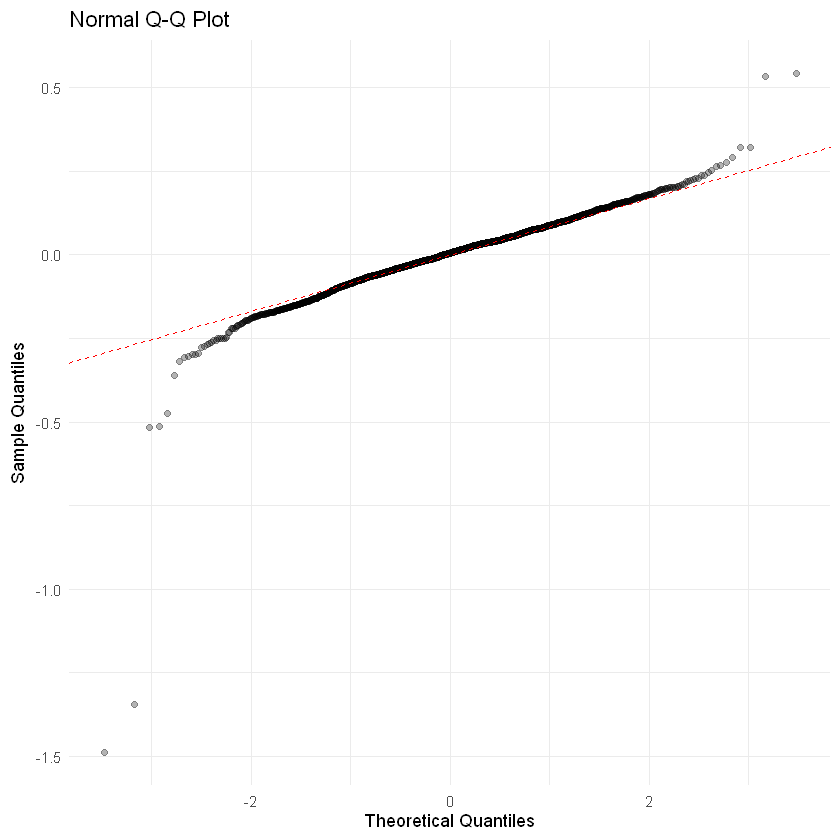

In [47]:
ggplot(data.frame(residuals = fit$residuals), aes(sample = residuals)) +
  stat_qq(alpha = 0.3) +
  stat_qq_line(color = "red", linetype = "dashed") +
  labs(x = "Theoretical Quantiles", y = "Sample Quantiles",
       title = "Normal Q-Q Plot") +
  theme_minimal()